In [1]:
import jax
import jax.numpy as jnp
import jax.random as jr
import diffrax
import equinox as eqx
import optax
import numpy as np
import matplotlib.pyplot as plt

### What is a Neural ODE, and how does `diffrax` fit in?

A **Neural ODE** replaces the hand-written right-hand side of an ODE with a small neural network:

$$\dot{x} = f_\theta(t, x)$$

where $f_\theta$ is a neural network (here a small MLP) with trainable parameters $\theta$, instead of a fixed formula like $Fx$ or $y^2-1$. We don't tell the network the "true" dynamics — we only show it a target trajectory $x(t)$ (generated from the known ODE, same as in `toy_examples.ipynb`) and train $\theta$ so that *integrating* $f_\theta$ from $x(0)$ reproduces that trajectory.

**`diffrax`** is the JAX equivalent of `scipy.integrate.solve_ivp`: it numerically integrates $\dot x = f(t,x)$, but because it's built on JAX the whole solve can be **differentiated through** — a loss computed from the solved trajectory can be backpropagated all the way into $f$'s parameters. The core call:

```python
term = diffrax.ODETerm(f)                 # wraps f(t, y, args) -> dy/dt
solver = diffrax.Tsit5()                  # adaptive explicit RK solver (like solve_ivp's default RK45)
sol = diffrax.diffeqsolve(
    term, solver, t0=t0, t1=t1, dt0=dt0, y0=y0,
    saveat=diffrax.SaveAt(ts=t_eval),               # like solve_ivp's t_eval
    adjoint=diffrax.RecursiveCheckpointAdjoint(),   # *how* gradients flow back through the solve
)
```

Once `diffeqsolve` is differentiable, training is a standard deep-learning loop:
1. **Forward pass** — integrate $f_\theta$ from $x_0$ to get a predicted trajectory $\hat{x}(t)$.
2. **Loss** — mean-squared error between $\hat x(t)$ and the target trajectory.
3. **Backward pass** — `diffrax`'s adjoint machinery differentiates the *entire solve* w.r.t. $\theta$.
4. **Update** — an optimizer (`optax.adam`) takes a gradient step on $\theta$.

Below, the same `VectorField` network class and `train_neural_ode` helper are reused for every example — only the target trajectory and initial condition change.

In [2]:
class VectorField(eqx.Module):
    """A small MLP mapping (t, x) -> dx/dt — stands in for the true ODE right-hand side."""
    mlp: eqx.nn.MLP

    def __init__(self, state_dim, width=32, depth=2, *, key):
        self.mlp = eqx.nn.MLP(
            in_size=state_dim + 1,       # state + time
            out_size=state_dim,
            width_size=width,
            depth=depth,
            activation=jax.nn.tanh,
            key=key,
        )

    def __call__(self, t, y, args):
        t = jnp.asarray([t])
        return self.mlp(jnp.concatenate([t, y]))


def predict(field, y0, ts, dt0=None):
    """Integrate any (t, y, args) -> dy/dt callable with diffrax and sample it at `ts`."""
    if dt0 is None:
        dt0 = float(ts[1] - ts[0])  # only safe to compute here when NOT inside a jit trace
    term = diffrax.ODETerm(field)
    sol = diffrax.diffeqsolve(
        term, diffrax.Tsit5(), t0=ts[0], t1=ts[-1], dt0=dt0,
        y0=y0, saveat=diffrax.SaveAt(ts=ts),
        adjoint=diffrax.RecursiveCheckpointAdjoint(),
        max_steps=10_000,
    )
    return sol.ys


def train_neural_ode(y0, ts, target, state_dim, steps=400, lr=1e-2, seed=0, width=32, depth=2):
    """Train a VectorField MLP so diffrax-integrating it from y0 matches `target` at `ts`."""
    key = jr.PRNGKey(seed)
    model = VectorField(state_dim, width=width, depth=depth, key=key)
    dt0 = float(ts[1] - ts[0])  # a plain Python float, computed once outside any jit trace

    @eqx.filter_value_and_grad
    def loss_fn(model):
        pred = predict(model, y0, ts, dt0=dt0)
        return jnp.mean((pred - target) ** 2)

    optimizer = optax.adam(lr)
    opt_state = optimizer.init(eqx.filter(model, eqx.is_array))

    @eqx.filter_jit
    def step(model, opt_state):
        loss, grads = loss_fn(model)
        updates, opt_state = optimizer.update(grads, opt_state, model)
        model = eqx.apply_updates(model, updates)
        return model, opt_state, loss

    pred_before = predict(model, y0, ts)
    losses = []
    for _ in range(steps):
        model, opt_state, loss = step(model, opt_state)
        losses.append(float(loss))
    pred_after = predict(model, y0, ts)

    return model, pred_before, pred_after, losses

## 1. Exponential growth / decay

$$\dot{x} = F x$$

with $F = -1$, $x(0) = 2$. Exact solution: $x(t) = x_0 e^{Ft}$.

**Neural ODE here:** the target trajectory is the exact exponential curve. `VectorField` starts as a random function of $(t,x)$; training pushes it toward the (very simple) map $f_\theta(t,x) \approx -x$, since that's the function whose integral curve from $x_0=2$ matches the target everywhere.

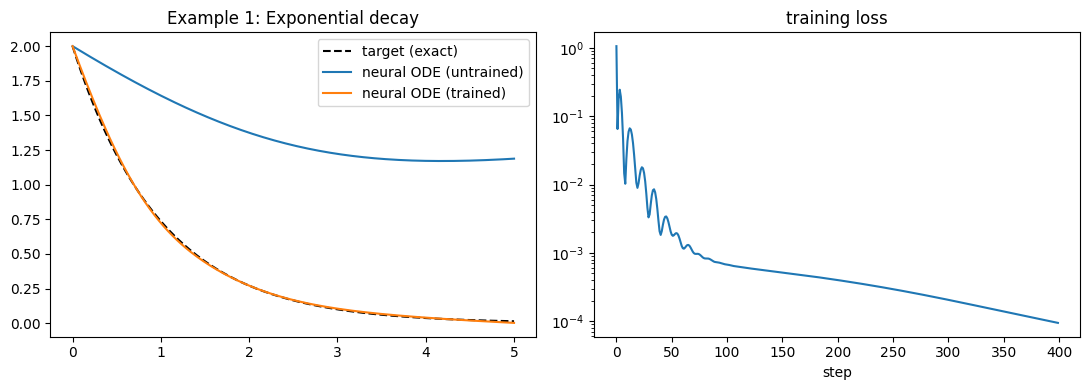

In [3]:
ts1 = jnp.linspace(0, 5, 200)
y0_1 = jnp.array([2.0])
target1 = (2 * jnp.exp(-ts1))[:, None]

model1, pred_before1, pred_after1, losses1 = train_neural_ode(y0_1, ts1, target1, state_dim=1, steps=400)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(ts1, target1[:, 0], "k--", label="target (exact)")
axes[0].plot(ts1, pred_before1[:, 0], label="neural ODE (untrained)")
axes[0].plot(ts1, pred_after1[:, 0], label="neural ODE (trained)")
axes[0].set_title("Example 1: Exponential decay")
axes[0].legend()
axes[1].semilogy(losses1)
axes[1].set_title("training loss")
axes[1].set_xlabel("step")
plt.tight_layout()
plt.show()

## 2. Linear ODE with forcing

$$\dot{x} = F x + L\, w(t)$$

with $F = -1$, $L = 2$, $w(t) = \sin(t)$, $x(0) = 0$.

**Neural ODE here:** unlike example 1, the true right-hand side depends explicitly on $t$ (through $w(t)$), not just on $x$. The target trajectory is generated by solving the *true* ODE with `diffrax` directly (playing the role of "data"); the neural vector field only ever sees $(t, x)$ pairs along that trajectory and has to discover the $\sin(t)$-driven forcing itself, purely from matching the curve — it never sees $w(t)$ explicitly.

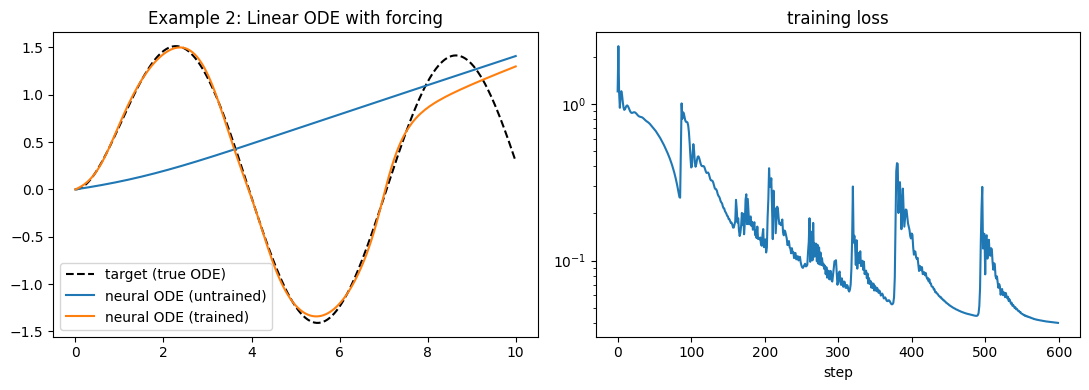

In [4]:
def true_ode2(t, x, args):
    F, L = -1.0, 2.0
    w = jnp.sin(t)
    return F * x + L * w

ts2 = jnp.linspace(0, 10, 200)
y0_2 = jnp.array([0.0])
target2 = predict(true_ode2, y0_2, ts2)

model2, pred_before2, pred_after2, losses2 = train_neural_ode(y0_2, ts2, target2, state_dim=1, steps=600)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(ts2, target2[:, 0], "k--", label="target (true ODE)")
axes[0].plot(ts2, pred_before2[:, 0], label="neural ODE (untrained)")
axes[0].plot(ts2, pred_after2[:, 0], label="neural ODE (trained)")
axes[0].set_title("Example 2: Linear ODE with forcing")
axes[0].legend()
axes[1].semilogy(losses2)
axes[1].set_title("training loss")
axes[1].set_xlabel("step")
plt.tight_layout()
plt.show()

## 3. Spring-mass system

$$\ddot{x} + \gamma \dot{x} + \nu^2 x = w(t)$$

or, as a first-order system with $x_1 = x$, $x_2 = \dot{x}$:

$$\dot{x}_1 = x_2, \qquad \dot{x}_2 = -\nu^2 x_1 - \gamma x_2 + w(t)$$

with $\gamma = 1$, $\nu = 2$, $w(t) = 0$, $x_1(0) = 1$, $x_2(0) = 0$.

**Neural ODE here:** the state is now 2-D ($x_1, x_2$), so `VectorField` outputs a 2-vector. The network has to learn both that $\dot x_1 = x_2$ (copying one component to the other output) *and* the damped restoring force for $\dot x_2$ — all purely from matching the 2-D trajectory, with a wider hidden layer (`width=48`) since it's a harder fit than the 1-D examples.

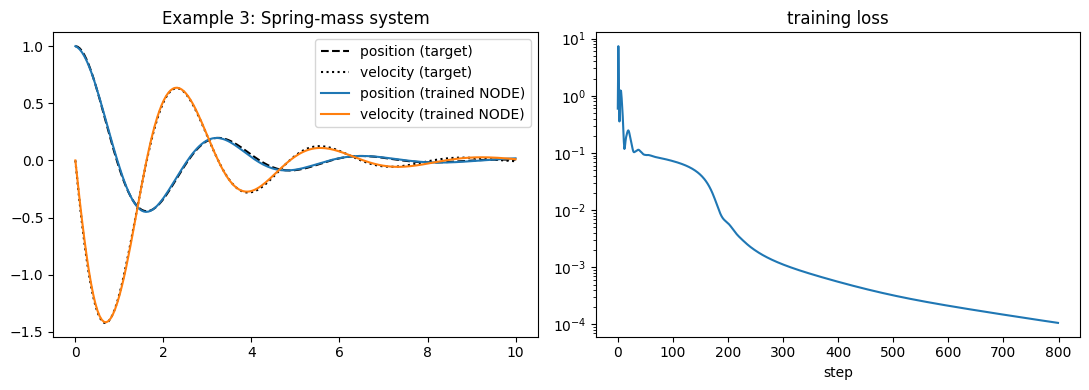

In [5]:
def true_spring(t, state, args):
    gamma, nu = 1.0, 2.0
    x1, x2 = state
    return jnp.array([x2, -nu**2 * x1 - gamma * x2])

ts3 = jnp.linspace(0, 10, 200)
y0_3 = jnp.array([1.0, 0.0])
target3 = predict(true_spring, y0_3, ts3)

model3, pred_before3, pred_after3, losses3 = train_neural_ode(y0_3, ts3, target3, state_dim=2, steps=800, width=48)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(ts3, target3[:, 0], "k--", label="position (target)")
axes[0].plot(ts3, target3[:, 1], "k:", label="velocity (target)")
axes[0].plot(ts3, pred_after3[:, 0], label="position (trained NODE)")
axes[0].plot(ts3, pred_after3[:, 1], label="velocity (trained NODE)")
axes[0].set_title("Example 3: Spring-mass system")
axes[0].legend()
axes[1].semilogy(losses3)
axes[1].set_title("training loss")
axes[1].set_xlabel("step")
plt.tight_layout()
plt.show()

## 4. Mean-reverting ODE

$$\dot{x} = \theta_1 (\theta_2 - x)$$

with $\theta_1 = 1.5$, $\theta_2 = 5$, $x(0) = 0$. Exact solution: $x(t) = \theta_2 + (x_0 - \theta_2) e^{-\theta_1 t}$.

**Neural ODE here:** the target is the exact relaxation curve. Since $f(t,x) = \theta_1(\theta_2 - x)$ doesn't depend on $t$, the network is free to find *any* function of $x$ alone that produces the same trajectory from $x_0 = 0$ — training recovers something close to the affine map $1.5(5 - x)$.

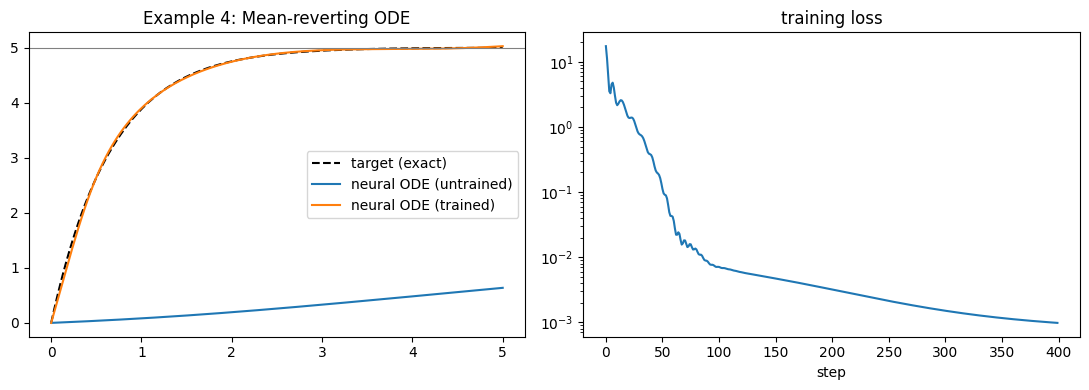

In [6]:
ts4 = jnp.linspace(0, 5, 150)
y0_4 = jnp.array([0.0])
theta1, theta2 = 1.5, 5.0
target4 = (theta2 + (y0_4[0] - theta2) * jnp.exp(-theta1 * ts4))[:, None]

model4, pred_before4, pred_after4, losses4 = train_neural_ode(y0_4, ts4, target4, state_dim=1, steps=400)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(ts4, target4[:, 0], "k--", label="target (exact)")
axes[0].plot(ts4, pred_before4[:, 0], label="neural ODE (untrained)")
axes[0].plot(ts4, pred_after4[:, 0], label="neural ODE (trained)")
axes[0].axhline(theta2, color="gray", linewidth=0.8)
axes[0].set_title("Example 4: Mean-reverting ODE")
axes[0].legend()
axes[1].semilogy(losses4)
axes[1].set_title("training loss")
axes[1].set_xlabel("step")
plt.tight_layout()
plt.show()

## 5. Pure exponential growth

$$\dot{x} = x$$

with $x(0) = 1$. Exact solution: $x(t) = x_0 e^{t}$.

**Neural ODE here:** unstable growth is a harder target for a `tanh`-activated MLP to match well, since $f_\theta$ has to reproduce an unbounded slope $\dot x = x$ purely by fitting pointwise trajectory values over the training window — shown mainly to contrast with the decaying example 1.

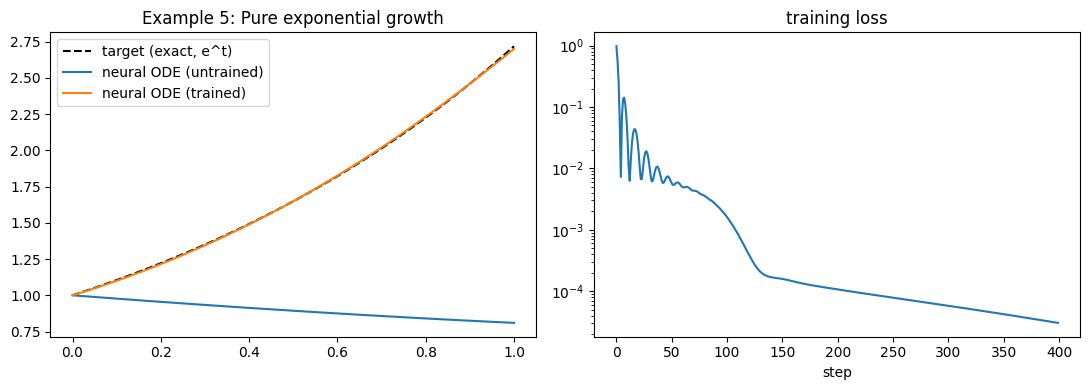

In [7]:
ts5 = jnp.linspace(0, 1, 100)
y0_5 = jnp.array([1.0])
target5 = jnp.exp(ts5)[:, None]

model5, pred_before5, pred_after5, losses5 = train_neural_ode(y0_5, ts5, target5, state_dim=1, steps=400)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(ts5, target5[:, 0], "k--", label="target (exact, e^t)")
axes[0].plot(ts5, pred_before5[:, 0], label="neural ODE (untrained)")
axes[0].plot(ts5, pred_after5[:, 0], label="neural ODE (trained)")
axes[0].set_title("Example 5: Pure exponential growth")
axes[0].legend()
axes[1].semilogy(losses5)
axes[1].set_title("training loss")
axes[1].set_xlabel("step")
plt.tight_layout()
plt.show()

## 6. Nonlinear ODE

$$\dot{y} = y^2 - 1$$

with $y(0) = 0$. Exact solution: $y(t) = -\tanh(t)$.

**Neural ODE here:** the true vector field is nonlinear in $y$ ($y^2 - 1$) but still autonomous; the MLP has to learn this shape purely from the trajectory. Since $\tanh$ is both the exact solution *and* the network's activation function here, this nonlinearity happens to be an easy one for it to match.

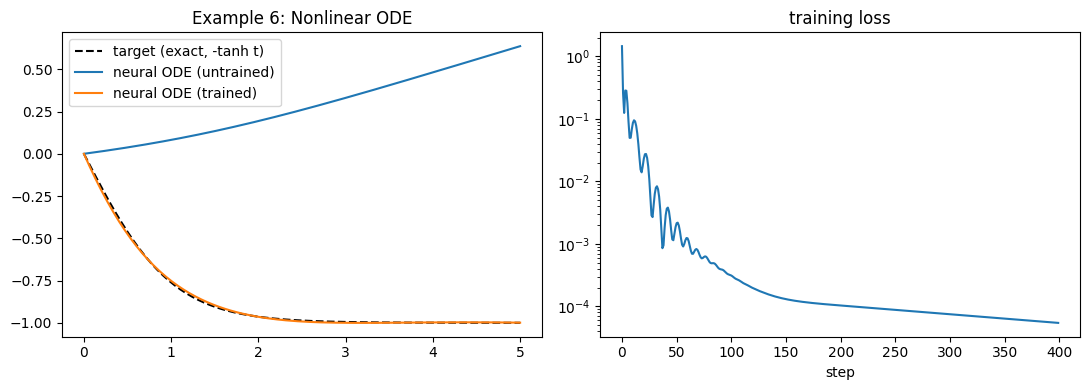

In [8]:
ts6 = jnp.linspace(0, 5, 150)
y0_6 = jnp.array([0.0])
target6 = (-jnp.tanh(ts6))[:, None]

model6, pred_before6, pred_after6, losses6 = train_neural_ode(y0_6, ts6, target6, state_dim=1, steps=400)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(ts6, target6[:, 0], "k--", label="target (exact, -tanh t)")
axes[0].plot(ts6, pred_before6[:, 0], label="neural ODE (untrained)")
axes[0].plot(ts6, pred_after6[:, 0], label="neural ODE (trained)")
axes[0].set_title("Example 6: Nonlinear ODE")
axes[0].legend()
axes[1].semilogy(losses6)
axes[1].set_title("training loss")
axes[1].set_xlabel("step")
plt.tight_layout()
plt.show()